# Olist CLV-ML — Exploratory Data Analysis

## Project Overview
This notebook explores the `clean.features` table to understand the distribution 
of Customer Lifetime Value (LTV) and the main behavioral features before modeling.

**Business Questions:**
- What is the expected monetary value of a new customer based on their first purchase?
- How much should be invested in acquiring a new customer given their profile?

**Target variable:** `total_ltv` — total spend per customer across all purchases  
**Dataset:** Brazilian E-Commerce Public Dataset by Olist (Kaggle)  
**Period:** September 2016 — October 2018  
**Customers:** 93358 unique customers

## 1. Setup

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

load_dotenv()
engine = create_engine(os.getenv("DATABASE_URL"))

print("Libraries loaded successfully")

Libraries loaded successfully


## 2. Load Data

In [14]:
df = pd.read_sql("SELECT * FROM clean.features", engine)
print(f"Shape: {df.shape}")
df.head()

Shape: (93358, 7)


,customer_unique_id,days_since_first_purchase,frequency,monetary,max_review_score,avg_review_score,total_ltv
0,0000366f3b9a7992bf8c76cfdf3221e2,160,1,129.90,5.0,5.0,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,18.90,4.0,4.0,18.90
2,0000f46a3911fa3c0805444483337064,586,1,69.00,3.0,3.0,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,25.99,4.0,4.0,25.99
4,0004aac84e0df4da2b147fca70cf8255,337,1,180.00,5.0,5.0,180.00


## 3. Data Overview

In [15]:
print("Shape")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

print("\nData Types")
print(df.dtypes)

print("\nMissing Values")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing': missing, 'percentage': missing_pct})
print(missing_df[missing_df['missing'] > 0])

Shape
Rows: 93,358
Columns: 7

Data Types
customer_unique_id               str
days_since_first_purchase      int64
frequency                      int64
monetary                     float64
max_review_score             float64
avg_review_score             float64
total_ltv                    float64
dtype: object

Missing Values
                  missing  percentage
max_review_score      603        0.65
avg_review_score      603        0.65


### Findings
- 93358 unique customers with 7 features
- 603 customers (0.65%) have no review score, they purchased but did not leave a review
- Missing values are minimal and will be handled during preprocessing

## 4. Target Variable Analysis: Total LTV

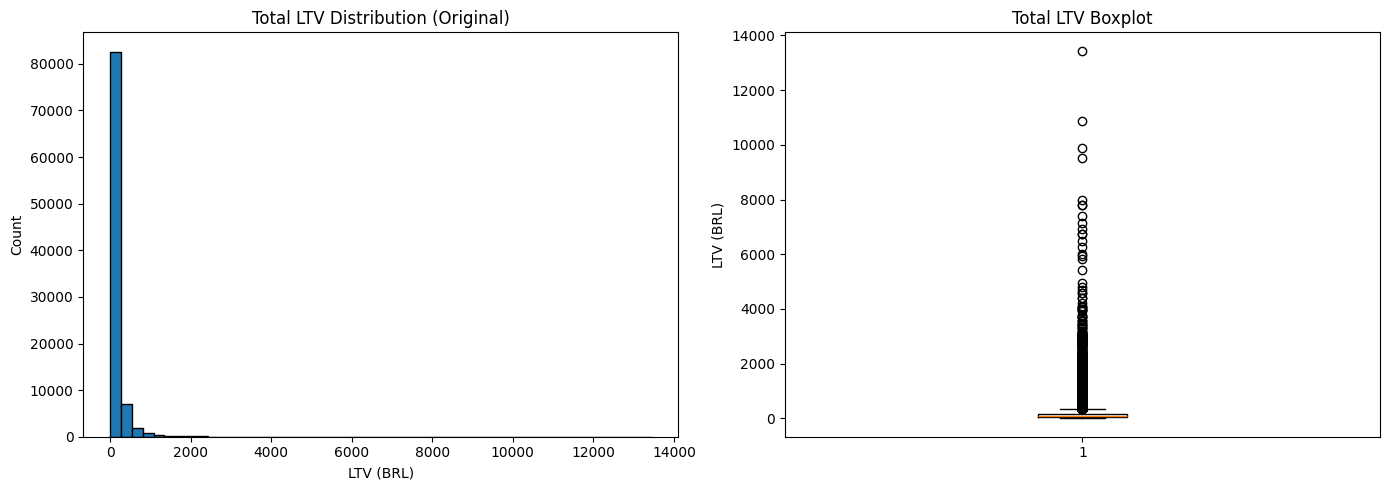

count    93358.00
mean       148.64
std        245.40
min          0.85
25%         48.90
50%         89.90
75%        159.90
max      13440.00
Name: total_ltv, dtype: float64


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['total_ltv'], bins=50, edgecolor='black')
axes[0].set_title('Total LTV Distribution (Original)')
axes[0].set_xlabel('LTV (BRL)')
axes[0].set_ylabel('Count')

axes[1].boxplot(df['total_ltv'], vert=True)
axes[1].set_title('Total LTV Boxplot')
axes[1].set_ylabel('LTV (BRL)')

plt.tight_layout()
plt.show()

print(df['total_ltv'].describe().round(2))

### Finding: Strong Right Skew

- Median LTV: BRL 89.90
- Mean LTV: BRL 148.64 Significantly higher than median, pulled by outliers
- Max LTV: BRL 13,440 150x the median value
- The distribution is heavily right-skewed, which is typical in e-commerce LTV data

**Decision:** Apply log transformation to normalize the distribution for modeling.

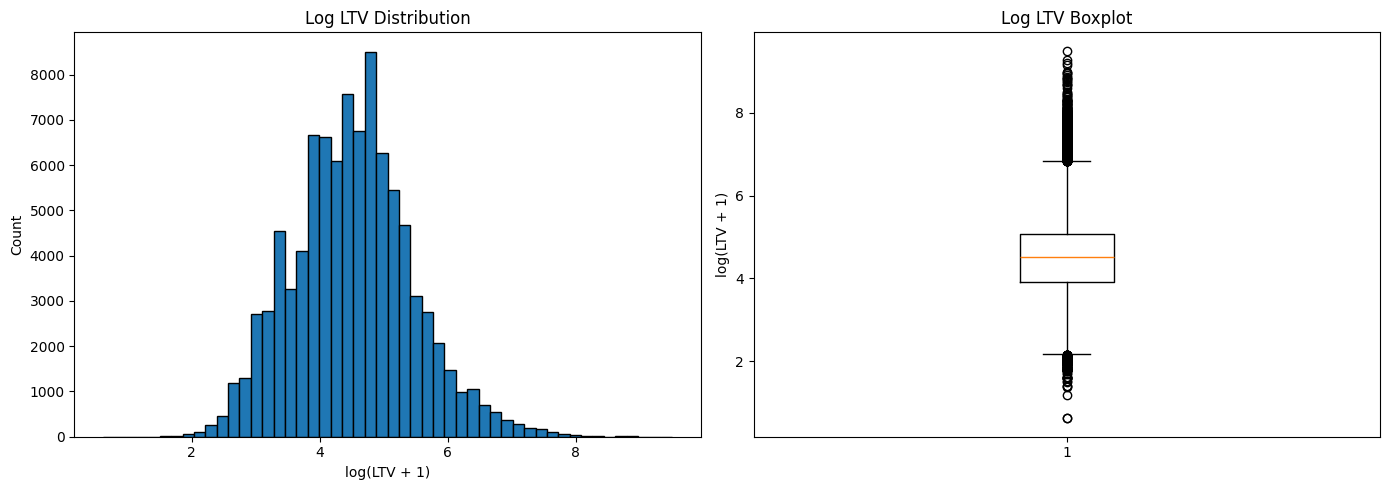

count    93358.0000
mean         4.5125
std          0.9368
min          0.6152
25%          3.9100
50%          4.5098
75%          5.0808
max          9.5061
Name: log_ltv, dtype: float64


In [17]:
df['log_ltv'] = np.log1p(df['total_ltv'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['log_ltv'], bins=50, edgecolor='black')
axes[0].set_title('Log LTV Distribution')
axes[0].set_xlabel('log(LTV + 1)')
axes[0].set_ylabel('Count')

axes[1].boxplot(df['log_ltv'], vert=True)
axes[1].set_title('Log LTV Boxplot')
axes[1].set_ylabel('log(LTV + 1)')

plt.tight_layout()
plt.show()

print(df['log_ltv'].describe().round(4))

### Log Transformation Result

After log transformation:
- Mean: 4.51 and Median: 4.51 Nearly identical, confirming normal distribution
- Range compressed from [0.85, 13,440] to [0.62, 9.51]
- Distribution is now suitable for linear modeling

**Note:** Predictions will be made in log scale and converted back with `np.expm1()`.

## 5. Feature Analysis

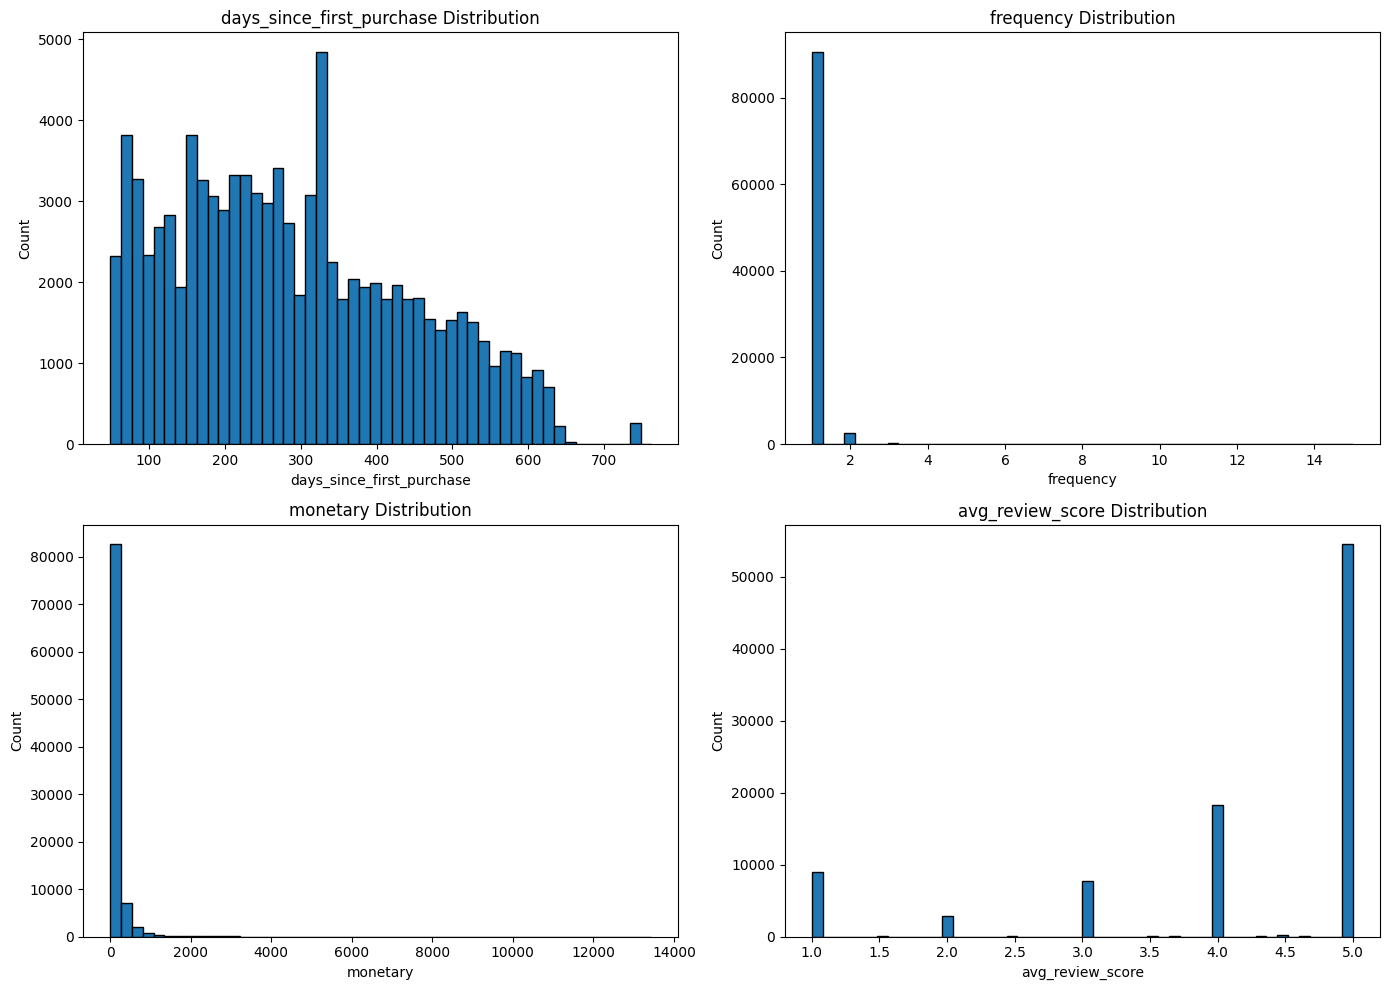

,days_since_first_purchase,frequency,monetary,avg_review_score
count,93358.00,93358.00,93358.00,92755.00
mean,289.12,1.03,148.64,4.15
std,153.10,0.21,245.40,1.28
min,49.00,1.00,0.85,1.00
25%,165.00,1.00,48.90,4.00
50%,270.00,1.00,89.90,5.00
75%,399.00,1.00,159.90,5.00
max,762.00,15.00,13440.00,5.00


In [18]:
features = ['days_since_first_purchase', 'frequency', 'monetary', 'avg_review_score']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col].dropna(), bins=50, edgecolor='black')
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

df[features].describe().round(2)

### Feature Findings

**days_since_first_purchase:**
- Range: 49 to 762 days
- Mean: 289 days, well distributed across the period

**frequency:**
- Mean: 1.03 Confirms that 97% of customers purchased only once
- Max: 15 A small group of highly engaged customers

**monetary:**
- Same distribution as total_ltv Strong right skew, will need log transformation
- Min: BRL 0.85, Max: BRL 13,440

**avg_review_score:**
- Range: 1 to 5
- Mean: 4.15 Customers tend to leave positive reviews
- 603 missing values (0.65%) Customers who purchased without reviewing

## 6. Correlation Analysis

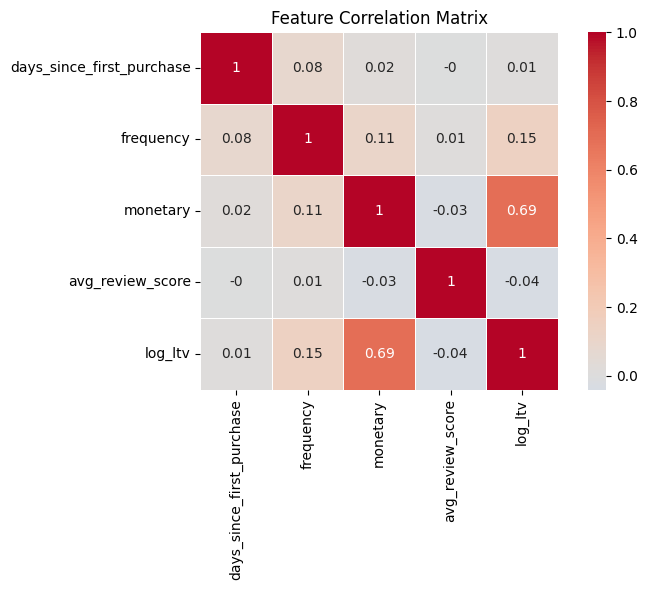

In [19]:
corr_cols = ['days_since_first_purchase', 'frequency', 'monetary', 
             'avg_review_score', 'log_ltv']

corr_matrix = df[corr_cols].corr().round(2)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()